## 0. Setup

In [5]:
# If running in Colab: clone your own repo (after you've pushed the src/ folder)
# or upload the src/ folder via the Colab file browser. Either way, src/ needs
# to be importable from this notebook's working directory.

!pip install -q tensorflow scikit-learn opencv-python-headless imagehash kagglehub matplotlib seaborn


In [6]:
import os
import sys
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import data
import models
import evaluate
import gradcam
import clean
import voc_crop

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU available: []


## 1. Dataset




In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download("andrewmvd/hard-hat-detection")
print("Downloaded to:", dataset_path)
print(os.listdir(dataset_path))


100%|██████████| 1.22G/1.22G [00:16<00:00, 78.8MB/s]


Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1
['images', 'annotations']


In [8]:
# Adjust these two paths once you've seen the actual folder names printed above
ANNOTATIONS_DIR = os.path.join(dataset_path, "annotations")
IMAGES_DIR = os.path.join(dataset_path, "images")

print(len(os.listdir(ANNOTATIONS_DIR)), "annotation files")
print(len(os.listdir(IMAGES_DIR)), "image files")


5000 annotation files
5000 image files


## 2. From detection boxes to a classification dataset

In [9]:
discovered = voc_crop.discover_classes(ANNOTATIONS_DIR)
print("Classes found in the XML annotations:")
for name, count in discovered.most_common():
    print(f"  {name!r}: {count}")


Classes found in the XML annotations:
  'helmet': 18966
  'head': 5785
  'person': 751


In [10]:
# EDIT THIS once you've seen the printed class names above.
# Map every raw class name -> "helmet", "no_helmet", or None (skip it).
# A common setup for this dataset is something like:
CLASS_MAP = {
    "helmet": "helmet",
    "head": "no_helmet",
    "person": None,   # whole-body boxes aren't useful for a head-level classifier
}

CROPPED_DIR = "../data/cropped"
crop_summary = voc_crop.crop_dataset(
    ANNOTATIONS_DIR, IMAGES_DIR, CROPPED_DIR, CLASS_MAP,
    min_box_size=20, padding_frac=0.10,
)
print(crop_summary)


{'written_per_class': {'helmet': 13443, 'no_helmet': 3635}, 'total_written': 17078, 'skipped_small_boxes': 7673, 'skipped_unmapped_boxes': 751, 'images_missing_on_disk': 0}


## 3. Cleaning: corrupted, duplicate, and unclear images





In [11]:
dry_run_summary = clean.clean_dataset(
    CROPPED_DIR, "../data/review", blur_threshold=15.0, dry_run=True
)
print("Dry run (nothing moved yet):")
print(dry_run_summary)


Dry run (nothing moved yet):
{'dry_run': True, 'total_flagged': 34, 'by_reason': {'blurry': 7, 'duplicate': 27}}


In [12]:
# Spot-check a handful of the flagged-blurry images before committing to the cleaning pass.
# Once you're satisfied with blur_threshold, re-run with dry_run=False:

final_clean_summary = clean.clean_dataset(
    CROPPED_DIR, "../data/review", blur_threshold=15.0, dry_run=False
)
print("After cleaning:")
print(final_clean_summary)


After cleaning:
{'dry_run': False, 'total_flagged': 34, 'by_reason': {'blurry': 7, 'duplicate': 27}}


Class balance after cleaning: {'helmet': 13410, 'no_helmet': 3634}


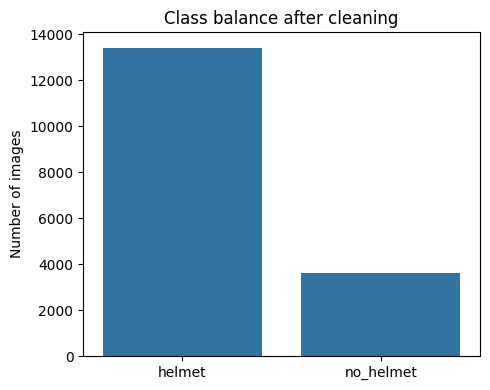

In [13]:
balance = clean.class_balance(CROPPED_DIR)
print("Class balance after cleaning:", balance)

pd.Series(balance).to_csv("../results/tables/class_balance.csv")

plt.figure(figsize=(5, 4))
sns.barplot(x=list(balance.keys()), y=list(balance.values()))
plt.title("Class balance after cleaning")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig("../results/figures/class_balance.png", dpi=150)
plt.show()


## 4. Train / validation / test split, normalization, and augmentation




In [14]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_ds, val_ds, test_ds, class_names = data.load_datasets(
    CROPPED_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED
)
print("Classes (alphabetical, index order used by the model):", class_names)

aug_layer = data.build_augmentation()


Found 17044 files belonging to 2 classes.
Using 11931 files for training.
Found 17044 files belonging to 2 classes.
Using 5113 files for validation.
Classes (alphabetical, index order used by the model): ['helmet', 'no_helmet']


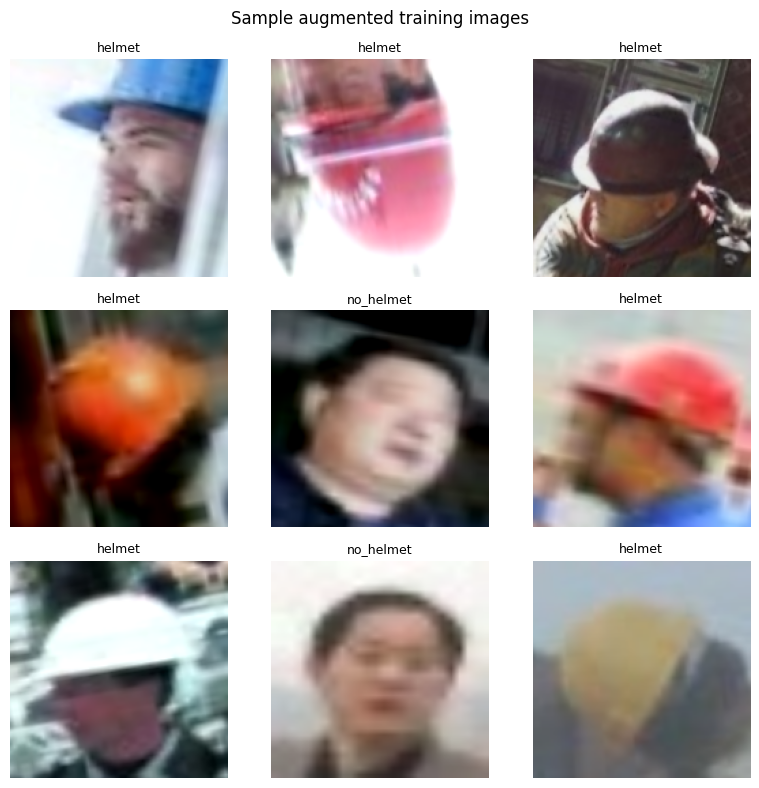

In [16]:
sample_batch, sample_labels = next(iter(train_ds.take(1)))
aug_batch = aug_layer(tf.cast(sample_batch, tf.float32), training=True)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img, label in zip(axes.flat, aug_batch.numpy(), sample_labels.numpy()):
    ax.imshow(img.astype("uint8"))
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample augmented training images")
plt.tight_layout()
plt.savefig("../results/figures/augmentation_samples.png", dpi=150)
plt.show()

## 5. Custom CNN baseline (trained from scratch)

In [17]:
cnn_train = data.prepare(train_ds, augment_layer=aug_layer, normalize=True, shuffle=True)
cnn_val = data.prepare(val_ds, normalize=True)
cnn_test = data.prepare(test_ds, normalize=True)

custom_cnn = models.build_custom_cnn(input_shape=IMG_SIZE + (3,))
models.compile_model(custom_cnn, lr=1e-3)
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("../results/custom_cnn_best.keras", save_best_only=True, monitor="val_loss"),
]

cnn_history = custom_cnn.fit(
    cnn_train, validation_data=cnn_val, epochs=2, callbacks=callbacks, verbose=1
)


Epoch 1/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 1287s 3s/step - accuracy: 0.8723 - loss: 0.3019 - val_accuracy: 0.6848 - val_loss: 0.6514
Epoch 2/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 1275s 3s/step - accuracy: 0.9191 - loss: 0.2037 - val_accuracy: 0.8832 - val_loss: 0.3188


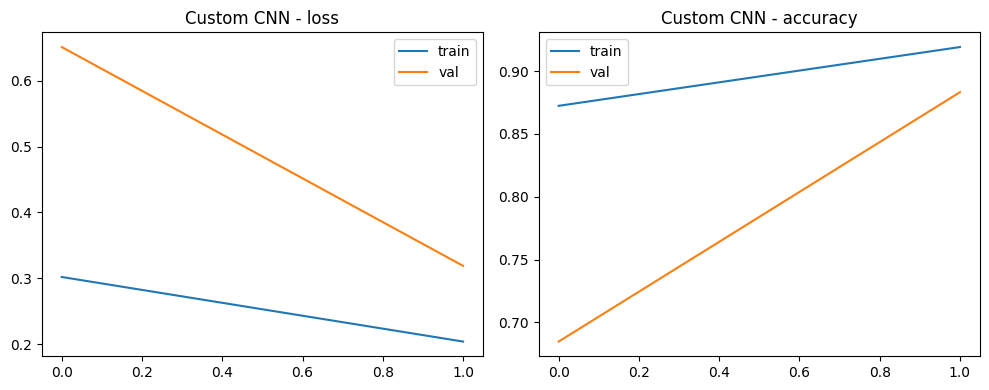

In [19]:
def plot_history(history, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} - loss"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} - accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"../results/figures/{save_name}.png", dpi=150)
    plt.show()

plot_history(cnn_history, "Custom CNN", "custom_cnn_history")


## 6. Transfer learning models



In [20]:
transfer_train = data.prepare(train_ds, augment_layer=aug_layer, normalize=False, shuffle=True)
transfer_val = data.prepare(val_ds, normalize=False)
transfer_test = data.prepare(test_ds, normalize=False)

BACKBONES = ["mobilenetv2", "resnet50"]
trained_models = {"custom_cnn": custom_cnn}
trained_bases = {}
histories = {"custom_cnn": cnn_history}



=== Training mobilenetv2 (frozen backbone) ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 343s 874ms/step - accuracy: 0.9233 - loss: 0.1914 - val_accuracy: 0.9582 - val_loss: 0.1041
Epoch 2/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 336s 886ms/step - accuracy: 0.9507 - loss: 0.1281 - val_accuracy: 0.9660 - val_loss: 0.0937


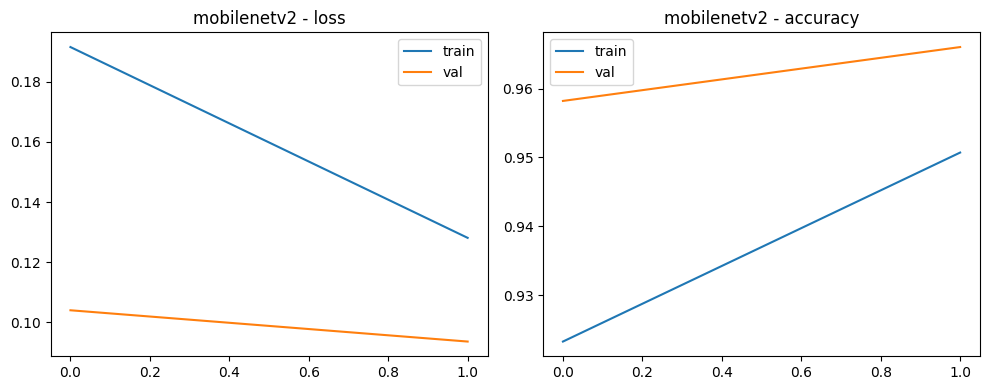


=== Training resnet50 (frozen backbone) ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 1367s 4s/step - accuracy: 0.9506 - loss: 0.1285 - val_accuracy: 0.9742 - val_loss: 0.0655
Epoch 2/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 1370s 4s/step - accuracy: 0.9708 - loss: 0.0864 - val_accuracy: 0.9766 - val_loss: 0.0601


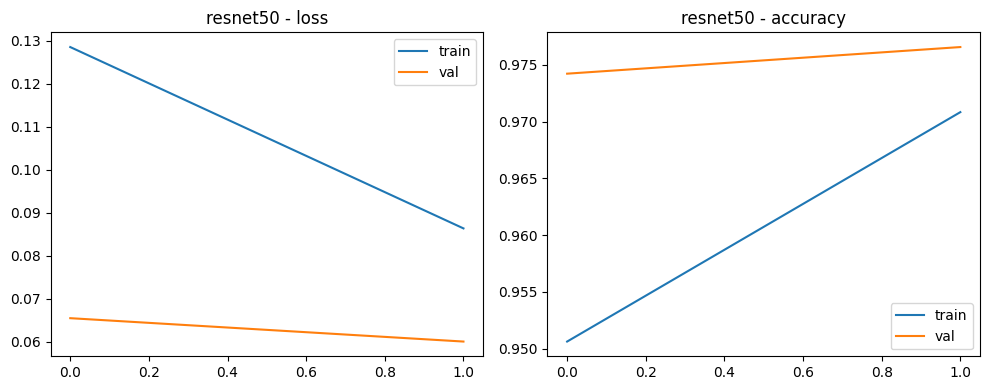

In [21]:
for backbone_name in BACKBONES:
    print(f"\n=== Training {backbone_name} (frozen backbone) ===")
    model, base = models.build_transfer_model(backbone_name, input_shape=IMG_SIZE + (3,), weights="imagenet")
    models.compile_model(model, lr=1e-3)

    cb = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(f"../results/{backbone_name}_best.keras", save_best_only=True, monitor="val_loss"),
    ]
    hist = model.fit(transfer_train, validation_data=transfer_val, epochs=2, callbacks=cb, verbose=1)

    trained_models[backbone_name] = model
    trained_bases[backbone_name] = base
    histories[backbone_name] = hist
    plot_history(hist, backbone_name, f"{backbone_name}_history")



=== Fine-tuning mobilenetv2 ===
Epoch 1/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.9416 - loss: 0.1469 - val_accuracy: 0.9570 - val_loss: 0.1055
Epoch 2/2
373/373 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.9631 - loss: 0.1014 - val_accuracy: 0.9637 - val_loss: 0.0933


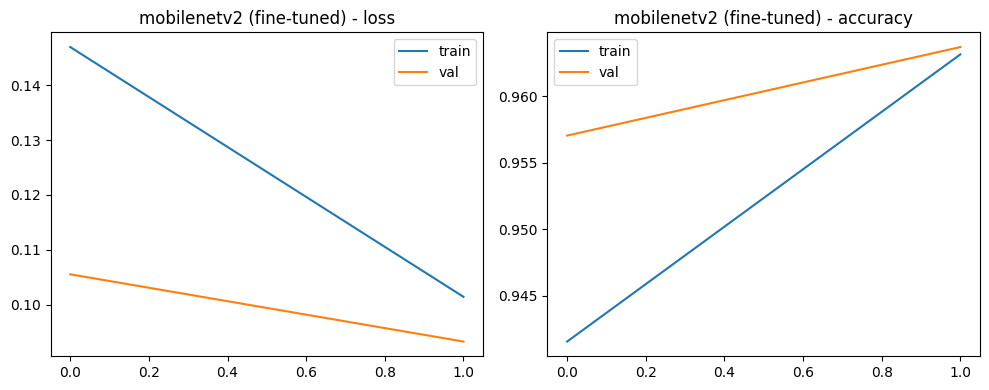


=== Fine-tuning resnet50 ===
Epoch 1/2
236/373 ━━━━━━━━━━━━━━━━━━━━ 13:39 6s/step - accuracy: 0.9524 - loss: 0.1212

KeyboardInterrupt: 

In [22]:
# Optional fine-tuning phase: unfreeze the top of each backbone and continue
# training a few more epochs at a lower learning rate. Skip this cell if
# you're short on Colab session time -- the frozen-backbone results above
# are already valid for comparison.

FINE_TUNE = True
FINE_TUNE_EPOCHS = 2
FINE_TUNE_LR = 1e-5

if FINE_TUNE:
    for backbone_name in BACKBONES:
        print(f"\n=== Fine-tuning {backbone_name} ===")
        model = trained_models[backbone_name]
        base = trained_bases[backbone_name]
        base.trainable = True
        # keep the first ~70% of layers frozen, only fine-tune the later ones
        freeze_until = int(len(base.layers) * 0.7)
        for layer in base.layers[:freeze_until]:
            layer.trainable = False

        models.compile_model(model, lr=FINE_TUNE_LR)
        cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)]
        hist_ft = model.fit(transfer_train, validation_data=transfer_val,
                             epochs=FINE_TUNE_EPOCHS, callbacks=cb, verbose=1)
        plot_history(hist_ft, f"{backbone_name} (fine-tuned)", f"{backbone_name}_finetune_history")


## 7. Evaluation: metrics, confusion matrices, ROC curves, inference time

In [23]:
results_rows = []
predictions = {}

for name, model in trained_models.items():
    test_set = cnn_test if name == "custom_cnn" else transfer_test
    y_true, y_prob, imgs = evaluate.collect_predictions(model, test_set)
    metrics = evaluate.compute_metrics(y_true, y_prob, class_names=class_names)
    bench = evaluate.benchmark_inference_time(model, imgs)

    predictions[name] = {"y_true": y_true, "y_prob": y_prob, "images": imgs}
    results_rows.append({
        "model": name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "params": bench["n_params"],
        "inference_ms": bench["mean_ms"],
    })
    print(f"\n--- {name} ---")
    print(metrics["classification_report"])

results_df = pd.DataFrame(results_rows).set_index("model")
results_df.to_csv("../results/tables/model_comparison.csv")
results_df



--- custom_cnn ---
              precision    recall  f1-score   support

      helmet       0.88      0.99      0.93      2037
   no_helmet       0.95      0.45      0.61       516

    accuracy                           0.88      2553
   macro avg       0.92      0.72      0.77      2553
weighted avg       0.89      0.88      0.87      2553


--- mobilenetv2 ---
              precision    recall  f1-score   support

      helmet       0.99      0.97      0.98      2035
   no_helmet       0.90      0.97      0.94       518

    accuracy                           0.97      2553
   macro avg       0.95      0.97      0.96      2553
weighted avg       0.98      0.97      0.97      2553


--- resnet50 ---
              precision    recall  f1-score   support

      helmet       0.98      0.99      0.99      2031
   no_helmet       0.97      0.92      0.94       522

    accuracy                           0.98      2553
   macro avg       0.97      0.96      0.97      2553
weighted avg   

,accuracy,precision,recall,f1,roc_auc,params,inference_ms
model,,,,,,,
custom_cnn,0.884450,0.954733,0.449612,0.611331,0.962912,258881,115.972827
mobilenetv2,0.973756,0.904847,0.972973,0.937674,0.995965,2259265,203.596822
resnet50,0.978065,0.969758,0.921456,0.944990,0.995921,23589761,235.938730


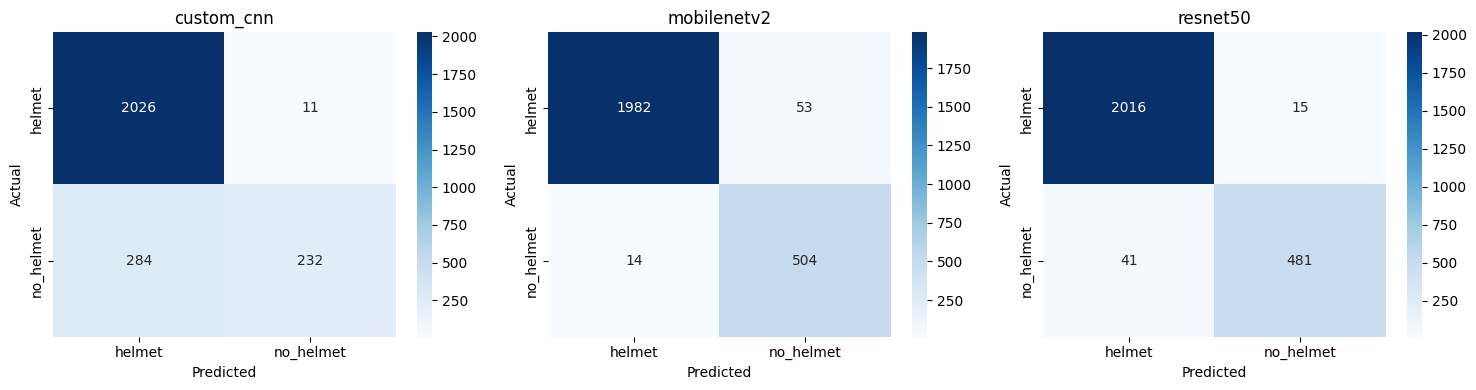

In [24]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, trained_models.items()):
    y_true = predictions[name]["y_true"]
    y_prob = predictions[name]["y_prob"]
    metrics = evaluate.compute_metrics(y_true, y_prob, class_names=class_names)
    sns.heatmap(metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrices.png", dpi=150)
plt.show()


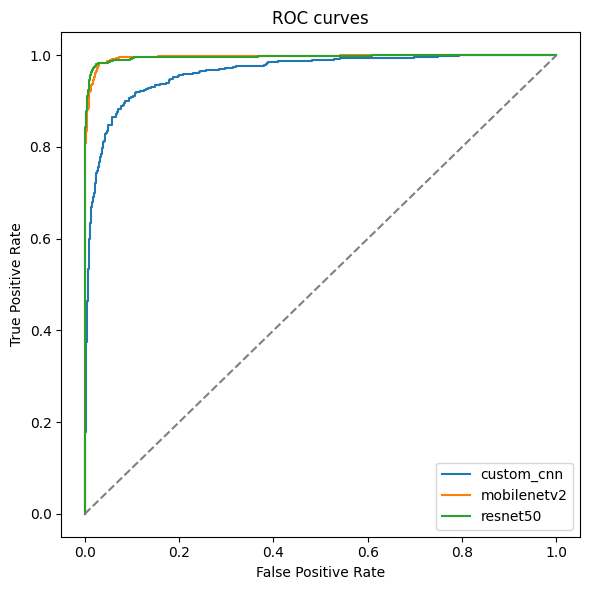

In [25]:
plt.figure(figsize=(6, 6))
for name in trained_models:
    fpr, tpr = evaluate.roc_points(predictions[name]["y_true"], predictions[name]["y_prob"])
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves"); plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/roc_curves.png", dpi=150)
plt.show()


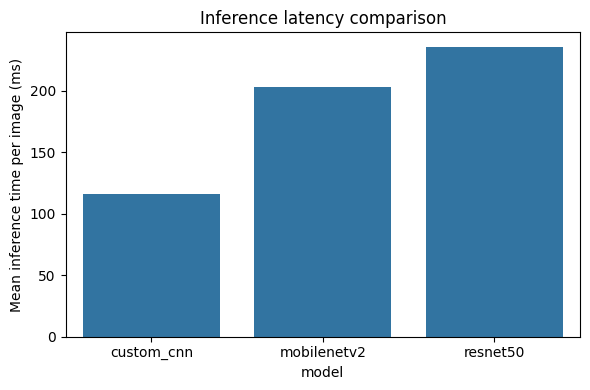

In [26]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results_df.reset_index(), x="model", y="inference_ms")
plt.ylabel("Mean inference time per image (ms)")
plt.title("Inference latency comparison")
plt.tight_layout()
plt.savefig("../results/figures/inference_time.png", dpi=150)
plt.show()


## 8. Explainability: Grad-CAM



In [27]:
def pick_examples(y_true, y_prob, threshold=0.5, n=3):
    y_pred = (y_prob >= threshold).astype(int)
    correct = np.where(y_pred == y_true)[0]
    false_pos = np.where((y_pred == 1) & (y_true == 0))[0]
    false_neg = np.where((y_pred == 0) & (y_true == 1))[0]
    return (correct[:n], false_pos[:n], false_neg[:n])


In [28]:
def show_gradcam_row(name, model, images, idx_list, title_prefix, base=None, preprocess_fn=None):
    if len(idx_list) == 0:
        print(f"No examples of type '{title_prefix}' found for {name} - good sign, or check threshold.")
        return
    fig, axes = plt.subplots(1, len(idx_list), figsize=(4 * len(idx_list), 4))
    if len(idx_list) == 1:
        axes = [axes]
    for ax, idx in zip(axes, idx_list):
        img = images[idx:idx+1]
        if name == "custom_cnn":
            heatmap = gradcam.gradcam_custom_cnn(model, img)
            display_img = (img[0] * 255).astype(np.uint8)
        else:
            heatmap = gradcam.gradcam_transfer_model(model, base, preprocess_fn, img)
            display_img = img[0].astype(np.uint8)
        overlay = gradcam.overlay_heatmap(display_img, heatmap)
        ax.imshow(overlay)
        ax.axis("off")
    plt.suptitle(f"{name} - {title_prefix}")
    plt.tight_layout()
    plt.savefig(f"../results/figures/gradcam_{name}_{title_prefix.replace(' ', '_')}.png", dpi=150)
    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_5']]
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


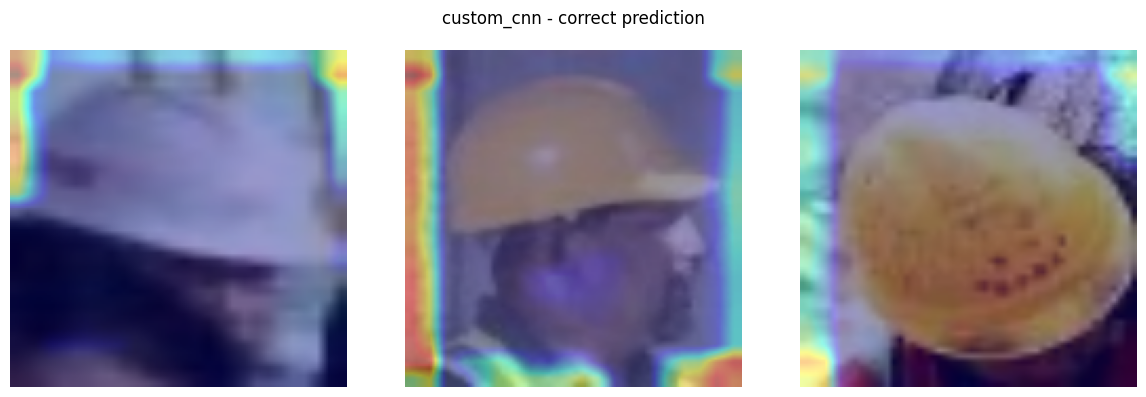

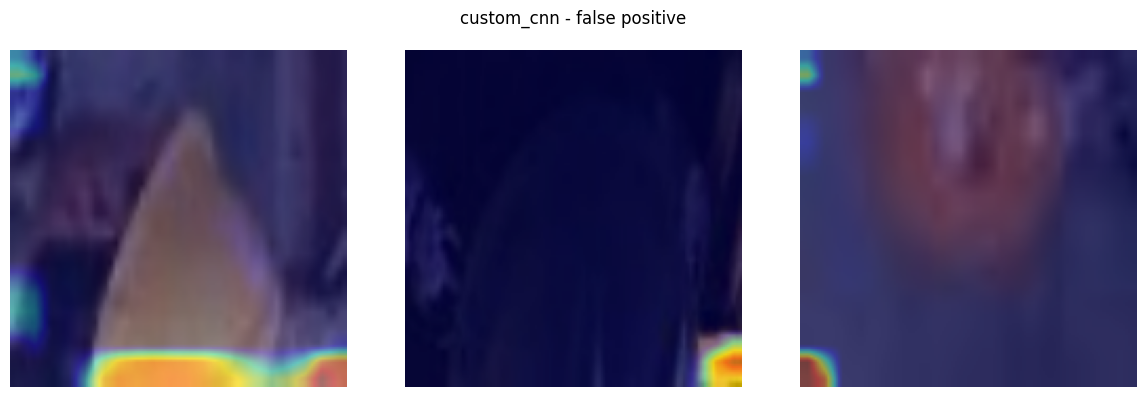

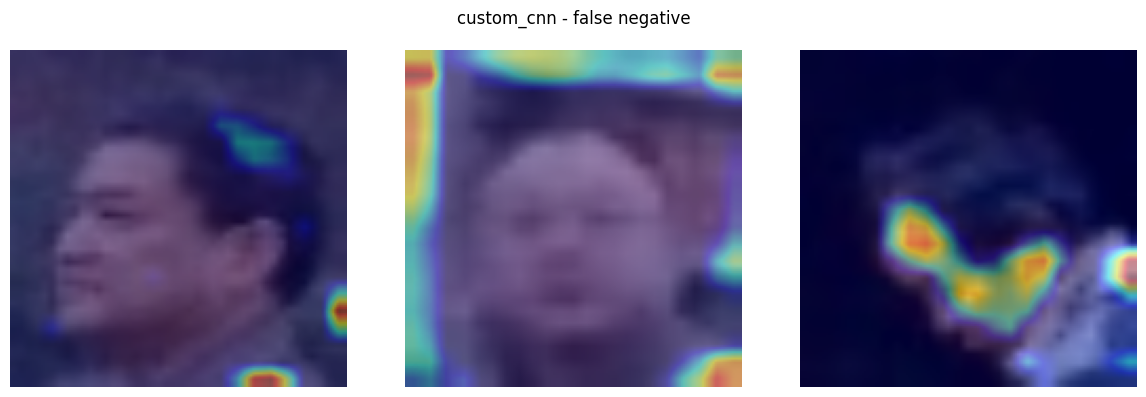

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_177']]
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133183093125440\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[101.      , 110.      , 119.      ],\n         [101.      , 110.      , 119.      ],\n         [101.      , 110.      , 119.      ],\n         ...,\n         [196.1875  , 201.1875  , 195.59375 ],\n         [197.      , 202.      , 196.      ],\n         [197.      , 202.      , 196.      ]],\n\n        [[101.015625, 110.015625, 118.984375],\n         [101.015625, 110.015625, 118.984375],\n         [101.02832 , 110.02832 , 118.99707 ],\n         ...,\n         [196.1875  , 201.1875  , 195.59375 ],\n         [197.      , 202.      , 196.      ],\n         [197.      , 202.      , 196.      ]],\n\n        [[101.359375, 110.359375, 118.640625],\n         [101.359375, 110.359375, 118.640625],\n         [101.65137 , 110.65137 , 118.93262 ],\n         ...,\n         [196.1875  , 201.1875  , 195.59375 ],\n         [197.      , 202. 

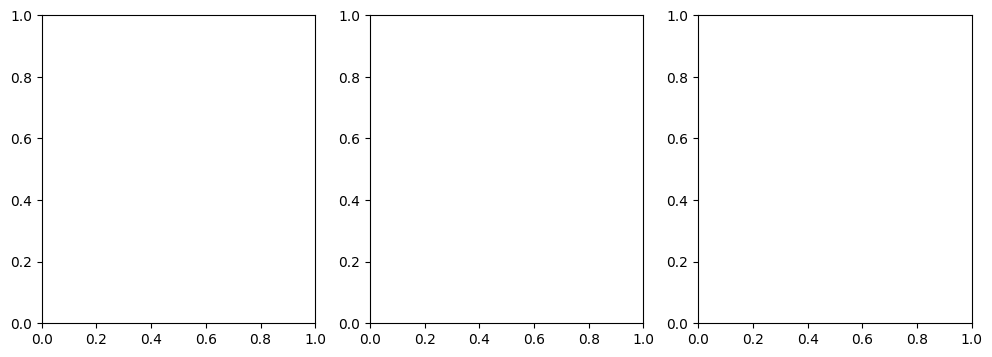

In [29]:
for name, model in trained_models.items():
    y_true = predictions[name]["y_true"]
    y_prob = predictions[name]["y_prob"]
    imgs = predictions[name]["images"]
    correct_idx, fp_idx, fn_idx = pick_examples(y_true, y_prob)

    base = trained_bases.get(name)
    preprocess_fn = models._PREPROCESS.get(name)

    show_gradcam_row(name, model, imgs, correct_idx, "correct prediction", base, preprocess_fn)
    show_gradcam_row(name, model, imgs, fp_idx, "false positive", base, preprocess_fn)
    show_gradcam_row(name, model, imgs, fn_idx, "false negative", base, preprocess_fn)


## 9. Error analysis



In [30]:
# Export a slightly larger set of FP/FN crops + their Grad-CAMs to a folder for closer review
# while writing the error-analysis section of the report.
import shutil

EXPORT_DIR = "../results/error_review"
os.makedirs(EXPORT_DIR, exist_ok=True)

for name, model in trained_models.items():
    y_true = predictions[name]["y_true"]
    y_prob = predictions[name]["y_prob"]
    imgs = predictions[name]["images"]
    _, fp_idx, fn_idx = pick_examples(y_true, y_prob, n=10)

    for kind, idx_list in [("false_positive", fp_idx), ("false_negative", fn_idx)]:
        out_dir = os.path.join(EXPORT_DIR, name, kind)
        os.makedirs(out_dir, exist_ok=True)
        for i, idx in enumerate(idx_list):
            img = imgs[idx]
            if name == "custom_cnn":
                arr = (img * 255).astype(np.uint8)
            else:
                arr = img.astype(np.uint8)
            tf.keras.utils.save_img(os.path.join(out_dir, f"{i}.jpg"), arr)

print("Exported FP/FN crops to", EXPORT_DIR)


Exported FP/FN crops to ../results/error_review


## 10. Results summary for the report



In [31]:
print(results_df.to_markdown())


| model       |   accuracy |   precision |   recall |       f1 |   roc_auc |           params |   inference_ms |
|:------------|-----------:|------------:|---------:|---------:|----------:|-----------------:|---------------:|
| custom_cnn  |   0.88445  |    0.954733 | 0.449612 | 0.611331 |  0.962912 | 258881           |        115.973 |
| mobilenetv2 |   0.973756 |    0.904847 | 0.972973 | 0.937674 |  0.995965 |      2.25926e+06 |        203.597 |
| resnet50    |   0.978065 |    0.969758 | 0.921456 | 0.94499  |  0.995921 |      2.35898e+07 |        235.939 |
